# surface stress 
- motivated by https://github.com/ACCESS-Community-Hub/access-cm3-paper-1/issues/42#issuecomment-3471199298

In [1]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'

# esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-virtual-datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/k10/qo9901/access-cm3-paper-figs/


### Note: In the cell above, we also have a `cm3-virtual-datastore` datastore. This is __an experimental datastore__ which has been virtualised, which should make it faster to load and read data. However, we are still developing the technology, so it may be missing some datasets that are found in the default: `cm3-demo-datastore`. If you have performance issues with the default, please try the virtual datastore, but please be aware of these limitations. Data within the virtual datastore references the same underlying data as the default datastore - it's simply a newer technology to improve performance. 

In [25]:
cm2_dir = '/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/'

In [2]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client

In [144]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34405 instead
  warnings.warn(


/proxy/34405/status


2025-11-10 16:01:05,931 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34043' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-6c6f835c1279180a978c6cf67bc12fd1', 77, 0, 0), ('rechunk-merge-6c6f835c1279180a978c6cf67bc12fd1', 55, 0, 0), ('concatenate-open_dataset-tauvo-original-getitem-9e7eb8d17353bd7cbf3eb2fa944677a7', 35, 0, 0), ('rechunk-merge-817fabb30dc9e46a6806c831e395f155', 54, 0, 0), ('rechunk-merge-817fabb30dc9e46a6806c831e395f155', 55, 0, 0), ('rechunk-merge-6c6f835c1279180a978c6cf67bc12fd1', 76, 0, 0), ('rechunk-merge-817fabb30dc9e46a6806c831e395f155', 77, 0, 0), ('rechunk-merge-6c6f835c1279180a978c6cf67bc12fd1', 54, 0, 0)} (stimulus_id='handle-worker-cleanup-1762750865.930813')
ERROR:asyncio:Task exception was never retrieved
future: <Task finished name='Task-10905506' coro=<Client._gather.<locals>.wait() done, defined at /g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-p

In [145]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34405/status,
Dashboard: /proxy/34405/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45519,Workers: 0
Dashboard: /proxy/34405/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34705,Total threads: 1
Dashboard: /proxy/44571/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:37517,


### Open the intake-esm datastore

In [4]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [5]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [6]:
datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

for col in COLUMNS_WITH_ITERABLES:
    datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

available_variables(datastore_filtered)

,variable_long_name,variable_standard_name,variable_cell_methods,variable_units
variable,,,,
Heat_PmE,Heat flux into ocean from mass flux into ocean,,area:mean yh:mean xh:mean time: mean,W m-2
KE,Layer kinetic energy per unit mass,,area:mean zl:mean yh:mean xh:mean time: mean,m2 s-2
Rd_dx,Ratio between deformation radius and grid spacing,,area:mean yh:mean xh:mean time: mean,m m-1
SSH,Sea Surface Height,,area:mean yh:mean xh:mean time: mean,m
SSU,Sea Surface Zonal Velocity,,yh:mean xq:point time: mean,m s-1
...,...,...,...,...
yh,h point nominal latitude,,,degrees_north
yq,q point nominal latitude,,,degrees_north
z_l,Depth at cell center,,,meters


In [82]:
tau_x = datastore.search(variable="tauuo", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).tauuo

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [83]:
tau_y = datastore.search(variable="tauvo", frequency="1mon").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).tauvo

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [23]:
import glob

In [26]:
# cm2 for same spinup from cold start time period
Filelist = sorted(
    sum(
        [glob.glob(os.path.join(cm2_dir, 'ocn', f'ocean-2d-tau_x-1-monthly-mean-ym_{yr:04}_*.nc')) for yr in range(1, 51)],
        []
    )
)

# Open as a single dataset
tau_x_cm2 = xr.open_mfdataset(
    Filelist,
    combine='by_coords',
    chunks={'time': -1, 'xt_ocean': 60}).chunk({'time':-1}).tau_x

Filelist = sorted(
    sum(
        [glob.glob(os.path.join(cm2_dir, 'ocn', f'ocean-2d-tau_y-1-monthly-mean-ym_{yr:04}_*.nc')) for yr in range(1, 51)],
        []
    )
)

# Open as a single dataset
tau_y_cm2 = xr.open_mfdataset(
    Filelist,
    combine='by_coords',
    chunks={'time': -1, 'xt_ocean': 60}).chunk({'time':-1}).tau_y

/jobfs/154218669.gadi-pbs/ipykernel_2649525/2660792261.py:10: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  tau_x_cm2 = xr.open_mfdataset(
/jobfs/154218669.gadi-pbs/ipykernel_2649525/2660792261.py:10: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  tau_x_cm2 = xr.open_mf

In [167]:
import cmocean
import numpy as np
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

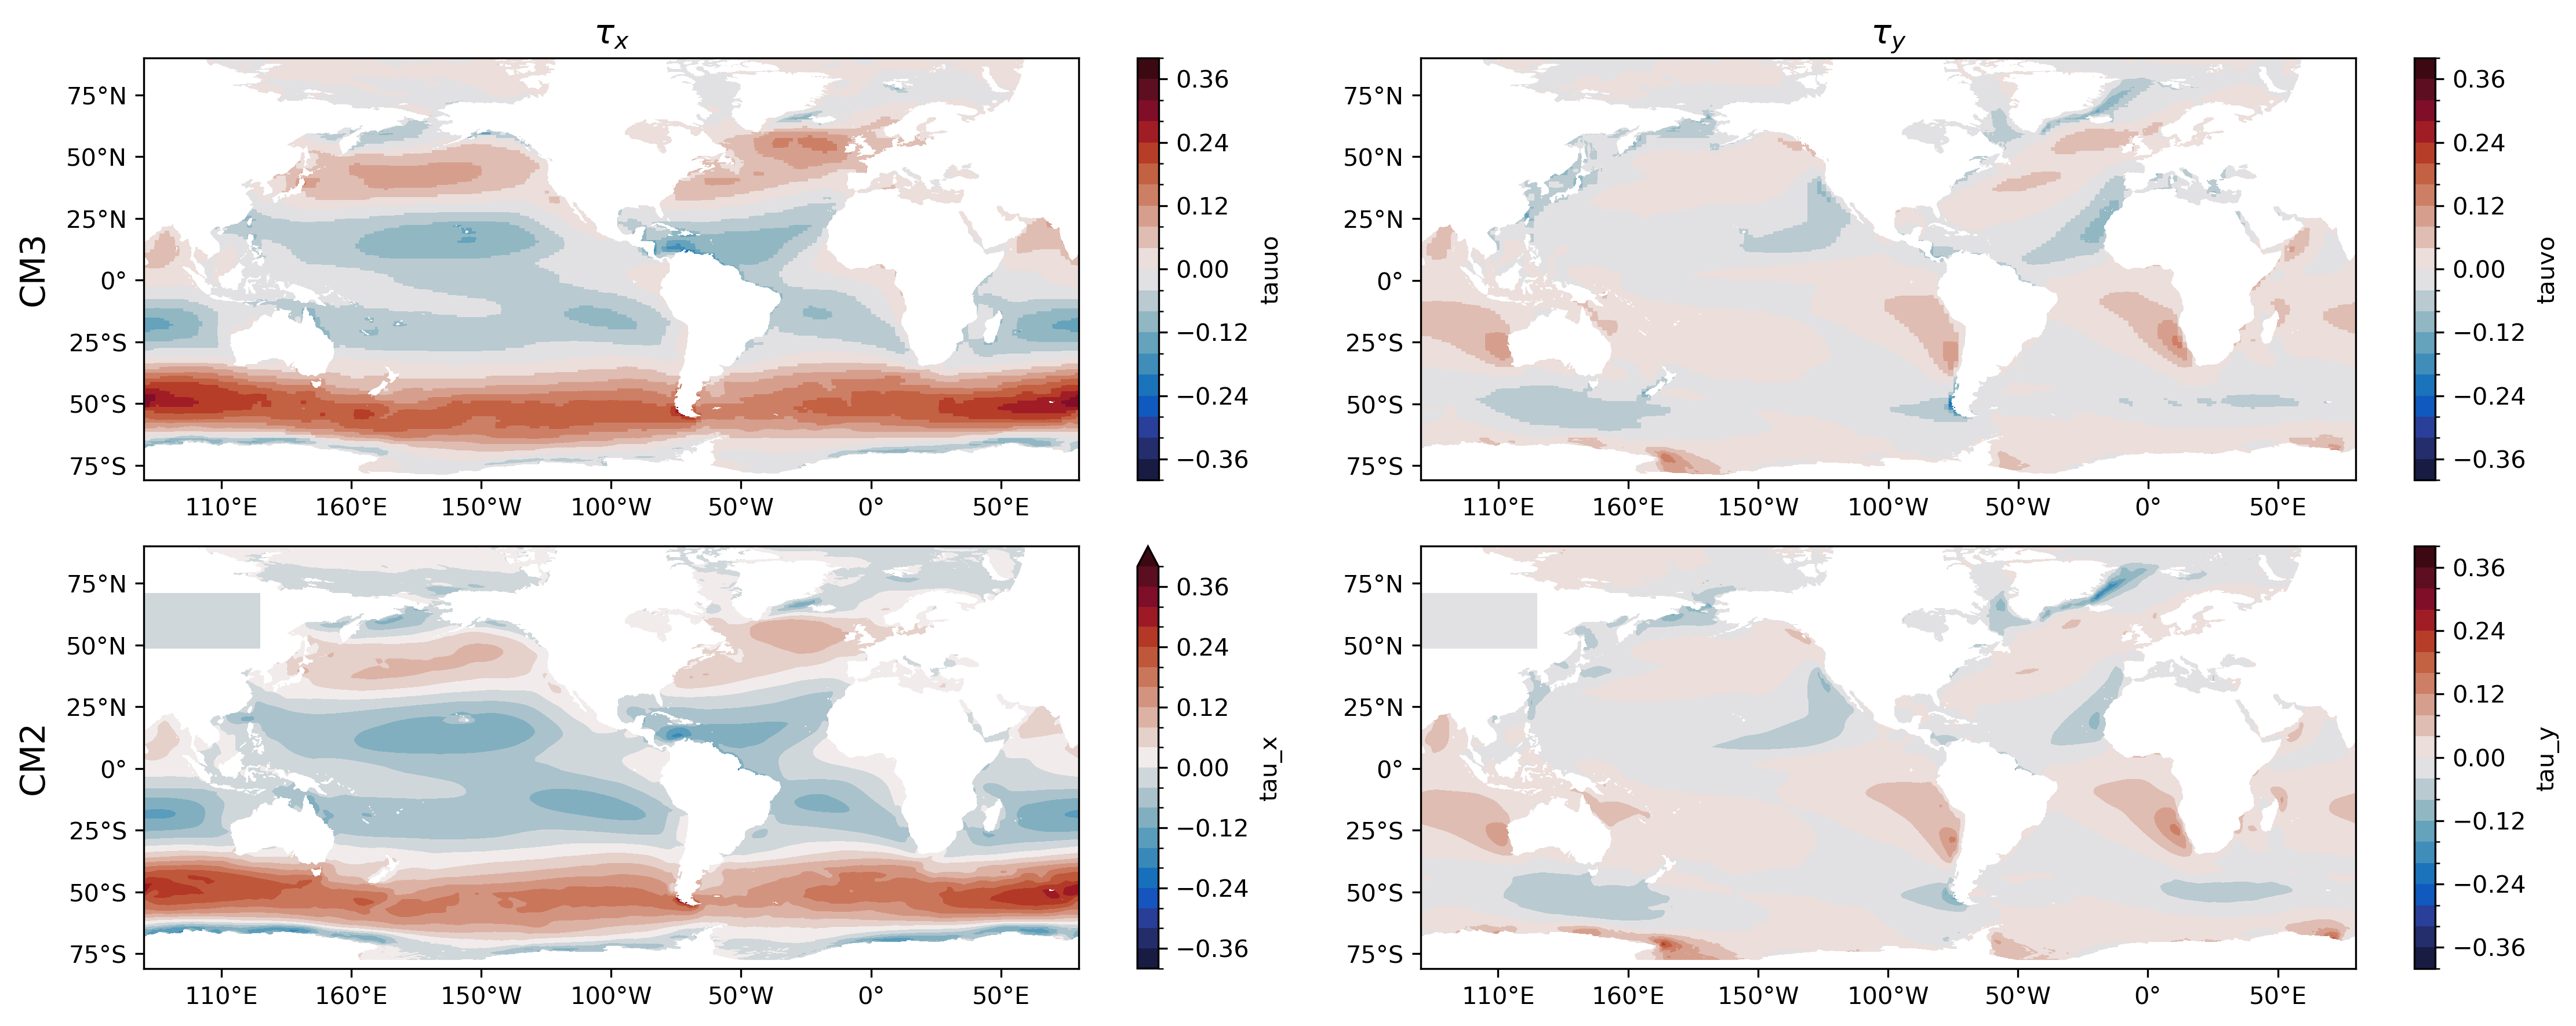

In [169]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 6))

# Compute means over final 10 years
cm3_tx = tau_x.isel(time = range(-10*12,0)).mean(dim='time')
cm3_ty = tau_y.isel(time = range(-10*12,0)).mean(dim='time')
cm2_tx = tau_x_cm2.isel(time = range(-10*12,0)).mean(dim='time')
cm2_ty = tau_y_cm2.isel(time = range(-10*12,0)).mean(dim='time')

# Determine shared color limits for consistency
vmin = -0.4 #min(cm3_tx.min(), cm3_ty.min(), cm2_tx.min(), cm2_ty.min())
vmax = 0.4 # max(cm3_tx.max(), cm3_ty.max(), cm2_tx.max(), cm2_ty.max())
levels_tau = np.linspace(vmin, vmax, 21)

# Plot without colorbars (we’ll add one shared later)
p1 = cm3_tx.plot.contourf(ax=ax[0,0],levels = levels_tau, cmap = cmocean.cm.balance)
p2 = cm3_ty.plot.contourf(ax=ax[0,1], levels = levels_tau, cmap = cmocean.cm.balance)
p3 = cm2_tx.plot.contourf(ax=ax[1,0],levels = levels_tau,  cmap = cmocean.cm.balance)
p4 = cm2_ty.plot.contourf(ax=ax[1,1], levels = levels_tau, cmap = cmocean.cm.balance) #transform=proj,

# Column and row titles
ax[0,0].set_title(r'$\tau_x$', fontsize=14)
ax[0,1].set_title(r'$\tau_y$', fontsize=14)

ax[0,0].text(-0.1, 0.5, 'CM3', va='center', ha='right', fontsize=14, transform=ax[0,0].transAxes, rotation=90)
ax[1,0].text(-0.1, 0.5, 'CM2', va='center', ha='right', fontsize=14, transform=ax[1,0].transAxes, rotation=90)

for i in range(0,2):
    for j in range(0,2):
        ax[i,j].set_ylabel('')
        ax[i,j].set_xlabel('')
        ax[i,j].yaxis.set_major_formatter(LatitudeFormatter())
        ax[i,j].xaxis.set_major_formatter(LongitudeFormatter())

plt.tight_layout()
plt.show()

## time series of tau over southern ocean

In [123]:
area_u = xr.open_mfdataset(cm2_dir + '/ocn/ocean-2d-area_u*.nc').area_u

/jobfs/154218669.gadi-pbs/ipykernel_2649525/2558146185.py:1: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  area_u = xr.open_mfdataset(cm2_dir + '/ocn/ocean-2d-area_u*.nc').area_u


In [53]:
areacello = datastore.search(variable="areacello").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime ob

In [67]:
areacello_cu = datastore.search(variable="areacello_cu").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xq": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
). areacello_cu

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime ob

In [152]:
areacello_cv = datastore.search(variable="areacello_cv").to_dask(
    xarray_combine_by_coords_kwargs = dict( # These kwargs can make things faster
        compat="override",
        data_vars="minimal",
        coords="minimal",
    ),
    xarray_open_kwargs = dict(
        chunks={"yq": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
). areacello_cv

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:101: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime ob

In [184]:
socean = [slice(-80,-35), slice(-280,80)]
## define south of 35S

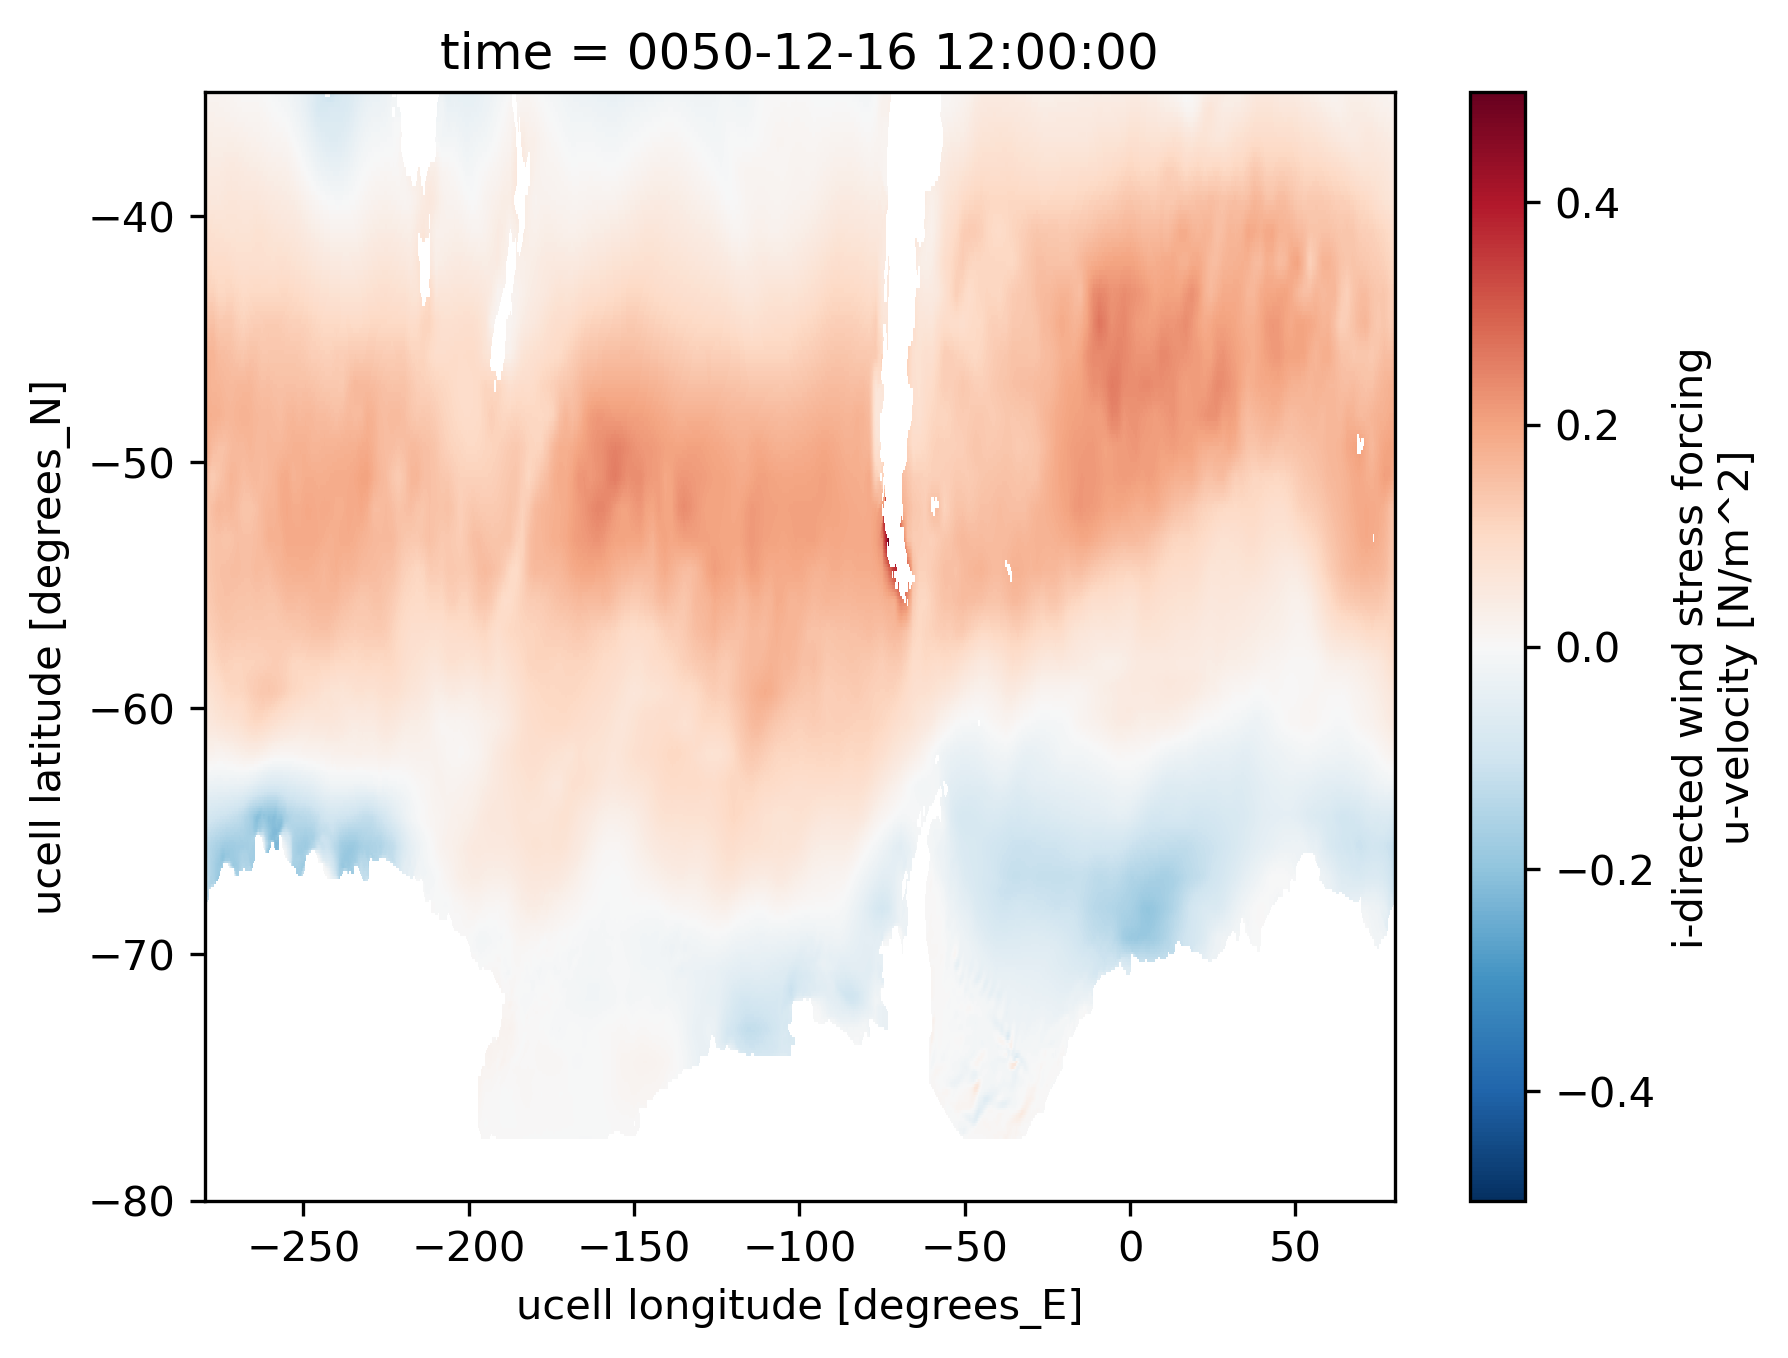

In [185]:
tau_x_cm2.sel(xu_ocean = socean[1], yu_ocean = socean[0]).isel(time = -1).plot()

In [186]:
tau_x_cm2_socean_t = tau_x_cm2.sel(xu_ocean = socean[1], yu_ocean = socean[0]).weighted(area_u.fillna(0)).mean(dim = {'xu_ocean','yu_ocean'}).load()
tau_y_cm2_socean_t = tau_y_cm2.sel(xu_ocean = socean[1], yu_ocean = socean[0]).weighted(area_u.fillna(0)).mean(dim = {'xu_ocean','yu_ocean'}).load()

In [187]:
tau_x_cm3_socean_t = tau_x.sel(xq = socean[1], yh = socean[0]).weighted(areacello_cu.fillna(0)).mean(dim = {'xq','yh'}).load()
tau_y_cm3_socean_t = tau_y.sel(xh = socean[1], yq = socean[0]).weighted(areacello_cv.fillna(0)).mean(dim = {'xh','yq'}).load()

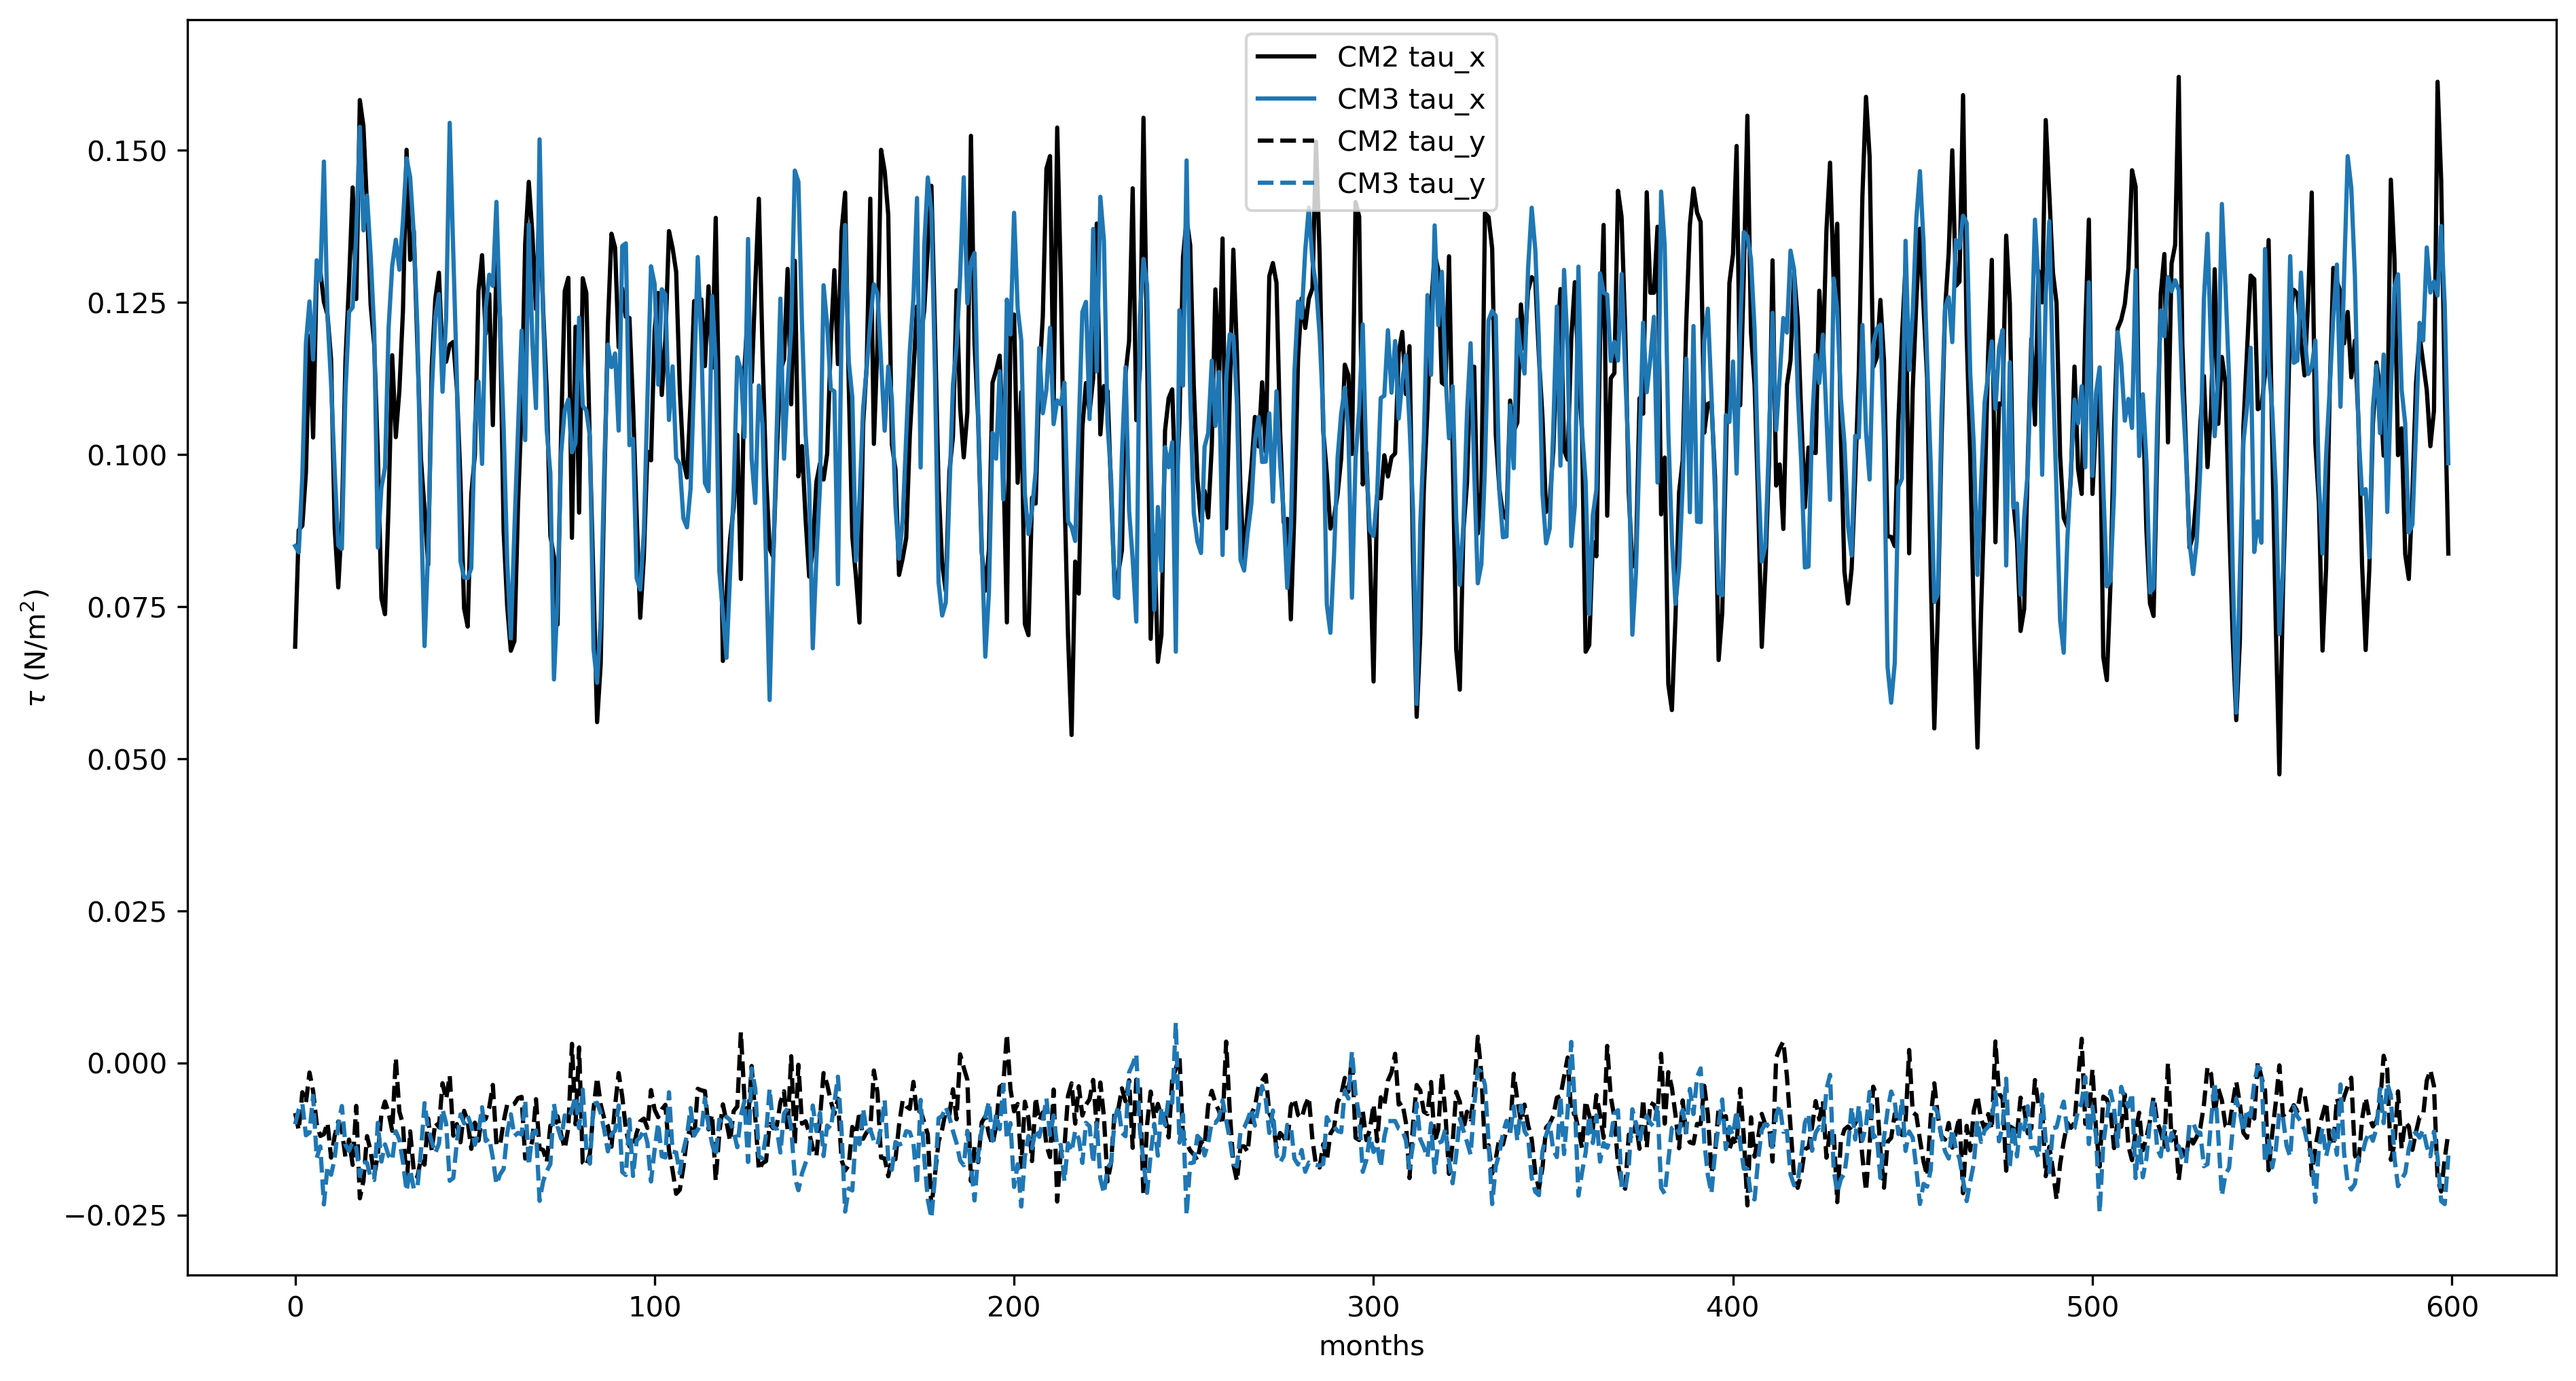

In [188]:
plt.figure(figsize = (15,8))
plt.plot(tau_x_cm2_socean_t.values, color = 'k', label = 'CM2 tau_x')
plt.plot(tau_x_cm3_socean_t.values, color = 'C0', label = 'CM3 tau_x')

plt.plot(tau_y_cm2_socean_t.values, color = 'k',linestyle = 'dashed', label = 'CM2 tau_y')
plt.plot(tau_y_cm3_socean_t.values, color = 'C0',linestyle = 'dashed', label = 'CM3 tau_y')
plt.ylabel(r'$\tau$ (N/m$^{2}$)')
plt.xlabel('months')
plt.legend()

#### Fixing the plot axes

Notice that the white land-masked regions are distorted away from the coastlines in the Arctic in the above plot. This is because a tripolar grid is used, so the grid lines are not zonal and meridional north of 65N, and consequently the nominal 1D coordinates `xh` and `yh` are incorrect. To fix this we need to use 2d coordinates `geolon` and `geolat`.

We can get these coorindates from the intake-esm datastore. However, note that `geolon` and `geolat` contain NaNs in regions where processors were masked over land. Below we replace these NaNs with zeros so that the coordinates can be used for plotting.

In [9]:
coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    xarray_open_kwargs = dict(
        use_cftime=True
    )
).compute()
coords = coords.fillna(0.0)

zos = zos.assign_coords(coords)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


Now try that plot again, this time using `geolon` and `geolat`.

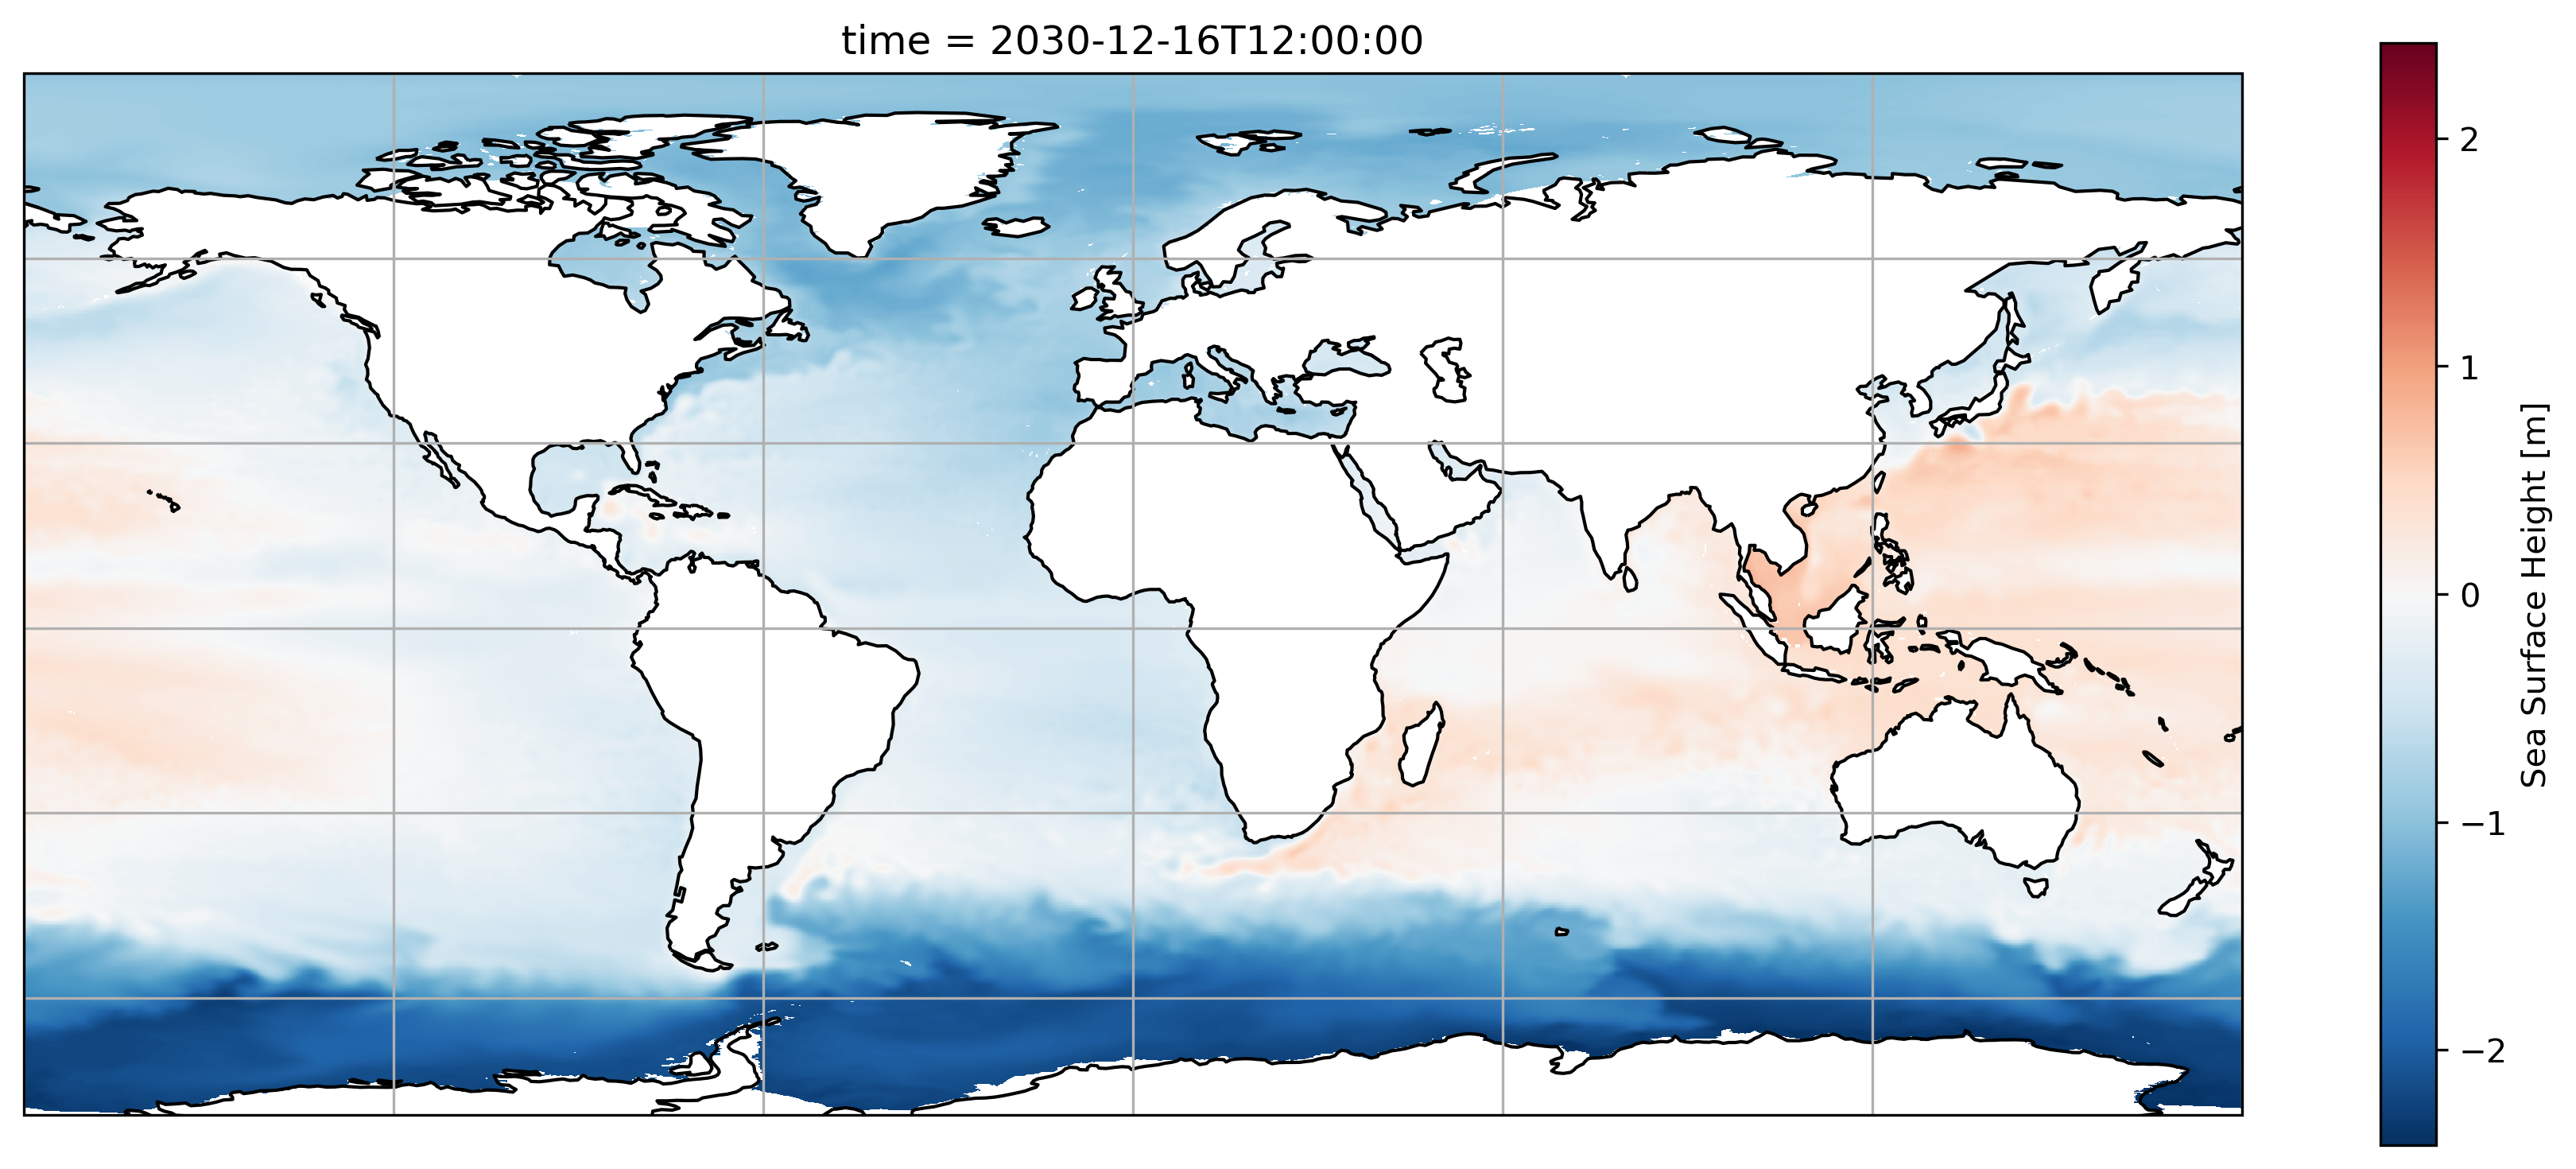

In [10]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,6), subplot_kw=dict(projection=proj))

zos["SSH"].isel(time=-1).plot(ax=ax, x="geolon", y="geolat")

ax.coastlines()
_ = ax.gridlines()
plt.savefig(plotfolder+'exampleout.png')

In [11]:
client.close()